In [2]:
# Cell 1: Setup and imports
!pip install openai tenacity pandas numpy tiktoken
!pip install anthropic

import json
import pandas as pd
import numpy as np
import pickle
from datetime import datetime
from tenacity import retry, stop_after_attempt, wait_exponential
import time
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports loaded")

   ---------------------------------------- 0.0/753.6 kB ? eta -:--:--
   - -------------------------------------- 30.7/753.6 kB 1.3 MB/s eta 0:00:01
   -------------------------- ------------- 501.8/753.6 kB 7.8 MB/s eta 0:00:01
   ---------------------------------------- 753.6/753.6 kB 6.8 MB/s eta 0:00:00
✅ All imports loaded


In [3]:
# Cell 2: Load data from Notebooks 1 & 2
print("="*60)
print("📂 LOADING DATA FROM PREVIOUS NOTEBOOKS")
print("="*60)

# Load knowledge base (from Notebook 1)
with open('knowledge_base.json', 'r') as f:
    kb_data = json.load(f)
    kb_texts = [article['content'] for article in kb_data]
    kb_titles = [article['title'] for article in kb_data]
    kb_doc_ids = [article['doc_id'] for article in kb_data]
    kb_languages = [article['language'] for article in kb_data]

print(f"✅ Loaded {len(kb_texts)} knowledge articles from Notebook 1")

# Load tickets (from Notebook 1)
with open('byte_dance_tickets.json', 'r') as f:
    tickets_data = json.load(f)

print(f"✅ Loaded {len(tickets_data)} support tickets from Notebook 1")

# Load embeddings (from Notebook 2)
with open('kb_embeddings.pkl', 'rb') as f:
    kb_embeddings = pickle.load(f)

print(f"✅ Loaded embeddings with shape {kb_embeddings.shape} from Notebook 2")

# Load model info (from Notebook 2)
with open('model_info.json', 'r') as f:
    model_info = json.load(f)

print(f"✅ Loaded model info: {model_info['model_name']}")

📂 LOADING DATA FROM PREVIOUS NOTEBOOKS
✅ Loaded 7 knowledge articles from Notebook 1
✅ Loaded 50 support tickets from Notebook 1
✅ Loaded embeddings with shape (8, 384) from Notebook 2
✅ Loaded model info: all-MiniLM-L6-v2


In [4]:
# Cell 3: Define retrieval function (reused from Notebook 2)
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# Load the same embedding model
model = SentenceTransformer(model_info['model_name'])

def retrieve(query, k=3):
    """
    Retrieve top-k most relevant documents for a query
    """
    q_emb = model.encode([query])
    similarities = cosine_similarity(q_emb, kb_embeddings)[0]
    top_indices = np.argsort(similarities)[-k:][::-1]
    
    top_docs = [kb_texts[i] for i in top_indices]
    top_titles = [kb_titles[i] for i in top_indices]
    top_scores = [similarities[i] for i in top_indices]
    top_languages = [kb_languages[i] for i in top_indices]
    
    return top_docs, top_titles, top_scores, top_languages

# Test retrieval
test_query = tickets_data[0]['user_query']
docs, titles, scores, langs = retrieve(test_query, k=2)

print(f"🔍 Test query: '{test_query}'")
print(f"📄 Retrieved: {titles[0]} (score: {scores[0]:.3f})")

🔍 Test query: 'watermark issue with CapCut'
📄 Retrieved: CapCut Login Troubleshooting (score: 0.476)


In [5]:
# Cell 4: Define ByteDance-specific prompt templates
print("="*60)
print("📝 DEFINING PROMPT TEMPLATES")
print("="*60)

# System prompt for ByteDance support AI
BYTEDANCE_SYSTEM_PROMPT = """You are ByteAssist, ByteDance's official AI support assistant for TikTok, CapCut, and Lark.

Your guidelines:
1. Be helpful, accurate, and concise
2. Use information from the provided context only
3. If context doesn't contain answer, say "I don't have that information in my knowledge base"
4. Always maintain ByteDance's brand voice: professional, friendly, solution-oriented
5. For urgent issues (account security, payments), recommend contacting human support
6. Respond in the same language as the user's query

Return ONLY valid JSON in this exact format:
{
    "answer": "your detailed response here",
    "confidence_score": 0.0-1.0,
    "sources_used": ["source_title_1", "source_title_2"],
    "requires_human_escalation": false,
    "suggested_actions": ["action1", "action2"]
}
"""

def create_prompt(user_query, retrieved_docs, retrieved_titles, retrieved_scores):
    """
    Create a structured prompt for the LLM
    """
    # Format retrieved context
    context = ""
    for i, (doc, title, score) in enumerate(zip(retrieved_docs, retrieved_titles, retrieved_scores), 1):
        context += f"""
[SOURCE {i}]: {title} (relevance: {score:.2%})
Content: {doc}
"""
    
    user_prompt = f"""User Query: {user_query}

Retrieved Context:
{context}

Instructions:
- Answer based primarily on SOURCE 1 (highest relevance)
- If confidence_score < 0.5, set requires_human_escalation = true
- Provide 2-3 suggested_actions the user can take
- Respond in the same language as the user query

Generate JSON response:"""
    
    return user_prompt

# Test prompt creation
sample_query = "My TikTok views dropped suddenly"
sample_docs, sample_titles, sample_scores, _ = retrieve(sample_query, k=2)
sample_prompt = create_prompt(sample_query, sample_docs, sample_titles, sample_scores)

print("✅ Prompt template created")
print(f"\n📝 Sample prompt preview:")
print(sample_prompt[:500] + "...")

📝 DEFINING PROMPT TEMPLATES
✅ Prompt template created

📝 Sample prompt preview:
User Query: My TikTok views dropped suddenly

Retrieved Context:

[SOURCE 1]: TikTok Algorithm Guide 2025 (relevance: 41.06%)
Content: The TikTok algorithm prioritizes watch time (60%), completion rate (25%), and engagement (15%). For best results, post when your audience is active (7-9 PM local time).

[SOURCE 2]: Data Privacy at ByteDance (relevance: 39.22%)
Content: ByteDance complies with GDPR, CCPA, and PDPA. User data is encrypted at rest (AES-256) and in transit (TLS 1.3). Data retention ...


In [7]:
# Install Google Gemini package 
!pip install google-generativeai

INFO: pip is looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/155.1 kB ? eta -:--:--
   ---------------------------------------  153.6/155.1 kB ? eta -:--:--
   ---------------------------------------- 155.1/155.1 kB 1.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   --------------------------------- ------ 1.1/1.3 MB 35.0 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 16.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/173.3 kB ? eta -:--:--
   --------------------------------------- 173.3/173.3 kB 10.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/435.2 kB ? eta -:--:--
   ----------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.16.1 requires keras>=3.0.0, which is not installed.
feast 0.57.0 requires numpy<3,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
tensorflow-intel 2.16.1 requires ml-dtypes~=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-intel 2.16.1 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 5.29.6 which is incompatible.


In [8]:
# Cell 5: LLM client setup (FREE alternative using local/Gemini)
print("="*60)
print("🤖 SETTING UP LLM CLIENT")
print("="*60)

# Option 1: Using Google Gemini (FREE tier - recommended)
# Get free API key from https://aistudio.google.com/app/apikey
import google.generativeai as genai

# Enter your API key here (or set as environment variable)
# For ByteDance demo, you can also use a mock LLM for structure testing

USE_REAL_LLM = False  # Set to True if you have API key

if USE_REAL_LLM:
    # Replace with your actual API key
    genai.configure(api_key="YOUR_GEMINI_API_KEY")
    llm_model = genai.GenerativeModel('gemini-1.5-flash')
    print("✅ Gemini API configured")
else:
    # Mock LLM for structure testing (no API key needed)
    print("⚠️  Using mock LLM (set USE_REAL_LLM=True for actual responses)")
    print("   Mock mode still validates JSON structure and workflows")

🤖 SETTING UP LLM CLIENT
⚠️  Using mock LLM (set USE_REAL_LLM=True for actual responses)
   Mock mode still validates JSON structure and workflows


In [9]:
# Cell 6: LLM response generation function (mock mode)
import json
import re

def extract_json_from_response(response_text):
    """Extract JSON from LLM response (handles markdown code blocks)"""
    json_match = re.search(r'```json\s*(\{.*?\})\s*```', response_text, re.DOTALL)
    if json_match:
        return json_match.group(1)
    
    json_match = re.search(r'\{.*\}', response_text, re.DOTALL)
    if json_match:
        return json_match.group(0)
    
    return response_text

@retry(stop=stop_after_attempt(3), wait=wait_exponential(multiplier=1, min=2, max=10))
def generate_response(user_query, retrieved_docs, retrieved_titles, retrieved_scores, use_mock=False):
    """Generate structured JSON response using LLM or mock mode"""
    prompt = create_prompt(user_query, retrieved_docs, retrieved_titles, retrieved_scores)
    
    if use_mock or not USE_REAL_LLM:
        # Mock response for testing (no API call needed)
        confidence = float(np.mean(retrieved_scores))
        mock_response = {
            "answer": f"Based on ByteDance documentation: {retrieved_docs[0][:150]}... For more help, check our support center.",
            "confidence_score": round(confidence, 2),
            "sources_used": retrieved_titles[:2],
            "requires_human_escalation": confidence < 0.5,
            "suggested_actions": ["Check the ByteDance Help Center", "Try the troubleshooting steps above", "Contact support if issue persists"]
        }
        return mock_response
    
    # Real LLM call (only runs if USE_REAL_LLM = True)
    try:
        full_prompt = f"{BYTEDANCE_SYSTEM_PROMPT}\n\n{prompt}"
        
        # For Google Gemini
        model = genai.GenerativeModel('gemini-1.5-flash')
        response = model.generate_content(full_prompt)
        response_text = response.text
        
        # Extract and parse JSON
        json_str = extract_json_from_response(response_text)
        result = json.loads(json_str)
        
        # Validate required fields
        required_fields = ["answer", "confidence_score", "sources_used", "requires_human_escalation", "suggested_actions"]
        for field in required_fields:
            if field not in result:
                result[field] = None if field != "suggested_actions" else []
        
        return result
    
    except Exception as e:
        print(f"❌ LLM API error: {e}")
        # Fallback response
        return {
            "answer": "I'm having trouble generating a response. Please try again or contact ByteDance support.",
            "confidence_score": 0.3,
            "sources_used": [],
            "requires_human_escalation": True,
            "suggested_actions": ["Refresh and try again", "Contact ByteDance Support"]
        }

# Test the generation
test_response = generate_response(
    "How do I fix shadowban on TikTok?",
    ["Check account status", "Remove violating content", "Wait 72 hours"],
    ["Shadowban Guide", "Account Health"],
    [0.85, 0.72],
    use_mock=True
)

print("✅ Generation function ready")
print(f"\n📝 Test response (mock mode):")
print(json.dumps(test_response, indent=2))

✅ Generation function ready

📝 Test response (mock mode):
{
  "answer": "Based on ByteDance documentation: Check account status... For more help, check our support center.",
  "confidence_score": 0.78,
  "sources_used": [
    "Shadowban Guide",
    "Account Health"
  ],
  "requires_human_escalation": false,
  "suggested_actions": [
    "Check the ByteDance Help Center",
    "Try the troubleshooting steps above",
    "Contact support if issue persists"
  ]
}


In [10]:
# Cell 7: Batch process all tickets
print("="*60)
print("🔄 BATCH PROCESSING SUPPORT TICKETS")
print("="*60)

# Process first 10 tickets (or all if you want to wait longer)
num_to_process = min(10, len(tickets_data))
results = []

print(f"Processing {num_to_process} tickets...\n")

for i, ticket in enumerate(tickets_data[:num_to_process], 1):
    print(f"📝 [{i}/{num_to_process}] Processing ticket: {ticket['ticket_id']}")
    print(f"   Query: {ticket['user_query'][:60]}...")
    
    # Step 1: Retrieve relevant docs
    docs, titles, scores, langs = retrieve(ticket['user_query'], k=3)
    
    # Step 2: Generate LLM response
    response = generate_response(
        ticket['user_query'],
        docs,
        titles,
        scores,
        use_mock=not USE_REAL_LLM
    )
    
    # Step 3: Store results
    result = {
        "ticket_id": ticket['ticket_id'],
        "user_query": ticket['user_query'],
        "product": ticket['product'],
        "language": ticket['language'],
        "retrieved_docs": titles,
        "retrieval_scores": scores,
        "llm_answer": response['answer'],
        "confidence_score": response['confidence_score'],
        "sources_used": response['sources_used'],
        "requires_escalation": response['requires_human_escalation'],
        "suggested_actions": response['suggested_actions'],
        "processing_timestamp": datetime.now().isoformat()
    }
    
    results.append(result)
    
    # Print summary
    print(f"   ✅ Confidence: {response['confidence_score']:.2f} | Escalate: {response['requires_human_escalation']}")
    print(f"   📚 Sources: {', '.join(titles[:2])}")
    print()

print(f"✅ Processed {len(results)} tickets successfully")

🔄 BATCH PROCESSING SUPPORT TICKETS
Processing 10 tickets...

📝 [1/10] Processing ticket: TKT-202605-0001
   Query: watermark issue with CapCut...
   ✅ Confidence: 0.22 | Escalate: True
   📚 Sources: CapCut Login Troubleshooting, Shadowban Resolution Process

📝 [2/10] Processing ticket: TKT-202605-0002
   Query: watermark issue with CapCut...
   ✅ Confidence: 0.22 | Escalate: True
   📚 Sources: CapCut Login Troubleshooting, Shadowban Resolution Process

📝 [3/10] Processing ticket: TKT-202605-0003
   Query: follower issue with TikTok...
   ✅ Confidence: 0.32 | Escalate: True
   📚 Sources: TikTok Algorithm Guide 2025, Data Privacy at ByteDance

📝 [4/10] Processing ticket: TKT-202605-0004
   Query: notification issue with Lark...
   ✅ Confidence: 0.20 | Escalate: True
   📚 Sources: Lark Administration Guide, CapCut Login Troubleshooting

📝 [5/10] Processing ticket: TKT-202605-0005
   Query: follower issue with TikTok...
   ✅ Confidence: 0.32 | Escalate: True
   📚 Sources: TikTok Algorithm 

In [11]:
# Cell 8: Analyze response quality
print("="*60)
print("📊 RESPONSE QUALITY ANALYSIS")
print("="*60)

results_df = pd.DataFrame(results)

print("\n📈 Confidence Score Distribution:")
print(results_df['confidence_score'].describe())

print("\n⚠️ Escalation Rate:")
escalation_rate = results_df['requires_escalation'].mean()
print(f"   {escalation_rate:.1%} of queries require human escalation")

print("\n🎯 Average Confidence by Product:")
product_confidence = results_df.groupby('product')['confidence_score'].mean()
for product, conf in product_confidence.items():
    print(f"   {product}: {conf:.3f}")

print("\n🔍 Low Confidence Queries (<0.5):")
low_conf = results_df[results_df['confidence_score'] < 0.5]
for _, row in low_conf.iterrows():
    print(f"   - {row['user_query'][:50]}... (Conf: {row['confidence_score']:.2f})")

print("\n📚 Most Frequently Used Sources:")
all_sources = [source for sources in results_df['sources_used'] for source in sources]
source_counts = pd.Series(all_sources).value_counts()
for source, count in source_counts.head(5).items():
    print(f"   {source}: used {count} times")

📊 RESPONSE QUALITY ANALYSIS

📈 Confidence Score Distribution:
count    10.000000
mean      0.232000
std       0.054324
min       0.140000
25%       0.205000
50%       0.220000
75%       0.240000
max       0.320000
Name: confidence_score, dtype: float64

⚠️ Escalation Rate:
   100.0% of queries require human escalation

🎯 Average Confidence by Product:
   CapCut: 0.225
   Lark: 0.195
   TikTok: 0.320

🔍 Low Confidence Queries (<0.5):
   - watermark issue with CapCut... (Conf: 0.22)
   - watermark issue with CapCut... (Conf: 0.22)
   - follower issue with TikTok... (Conf: 0.32)
   - notification issue with Lark... (Conf: 0.20)
   - follower issue with TikTok... (Conf: 0.32)
   - watermark issue with CapCut... (Conf: 0.22)
   - calendar issue with Lark... (Conf: 0.14)
   - crash issue with CapCut... (Conf: 0.24)
   - notification issue with Lark... (Conf: 0.20)
   - permission issue with Lark... (Conf: 0.24)

📚 Most Frequently Used Sources:
   CapCut Login Troubleshooting: used 6 times
  

In [13]:
# Cell 9: Save results for Notebook 4 (with JSON serialization fix)
print("="*60)
print("💾 SAVING RESULTS FOR NOTEBOOK 4")
print("="*60)

# Convert numpy types to Python native types for JSON serialization
def convert_to_serializable(obj):
    """Convert numpy types to Python native types"""
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, pd.Timestamp):
        return obj.isoformat()
    elif isinstance(obj, (list, tuple)):
        return [convert_to_serializable(item) for item in obj]
    elif isinstance(obj, dict):
        return {key: convert_to_serializable(value) for key, value in obj.items()}
    return obj

# Convert results to serializable format
serializable_results = convert_to_serializable(results)

# Save full results
with open('llm_responses.json', 'w') as f:
    json.dump(serializable_results, f, indent=2)
print("✅ Saved: llm_responses.json")

# Save summary for quick analysis
summary = {
    "total_processed": len(results),
    "avg_confidence": float(results_df['confidence_score'].mean()),
    "escalation_rate": float(escalation_rate),
    "products": list(results_df['product'].unique()),
    "timestamp": datetime.now().isoformat(),
    "llm_mode": "mock" if not USE_REAL_LLM else "gemini",
    "avg_retrieval_k": 3
}

with open('llm_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print("✅ Saved: llm_summary.json")

# Create a sample output for README (convert to serializable)
sample_output = convert_to_serializable(results[0]) if results else {}
with open('sample_response.json', 'w') as f:
    json.dump(sample_output, f, indent=2)
print("✅ Saved: sample_response.json")

# Also save as CSV for easy viewing
results_df.to_csv('llm_responses.csv', index=False)
print("✅ Saved: llm_responses.csv")

print("\n📊 Files saved successfully with proper JSON formatting!")

💾 SAVING RESULTS FOR NOTEBOOK 4
✅ Saved: llm_responses.json
✅ Saved: llm_summary.json
✅ Saved: sample_response.json
✅ Saved: llm_responses.csv

📊 Files saved successfully with proper JSON formatting!


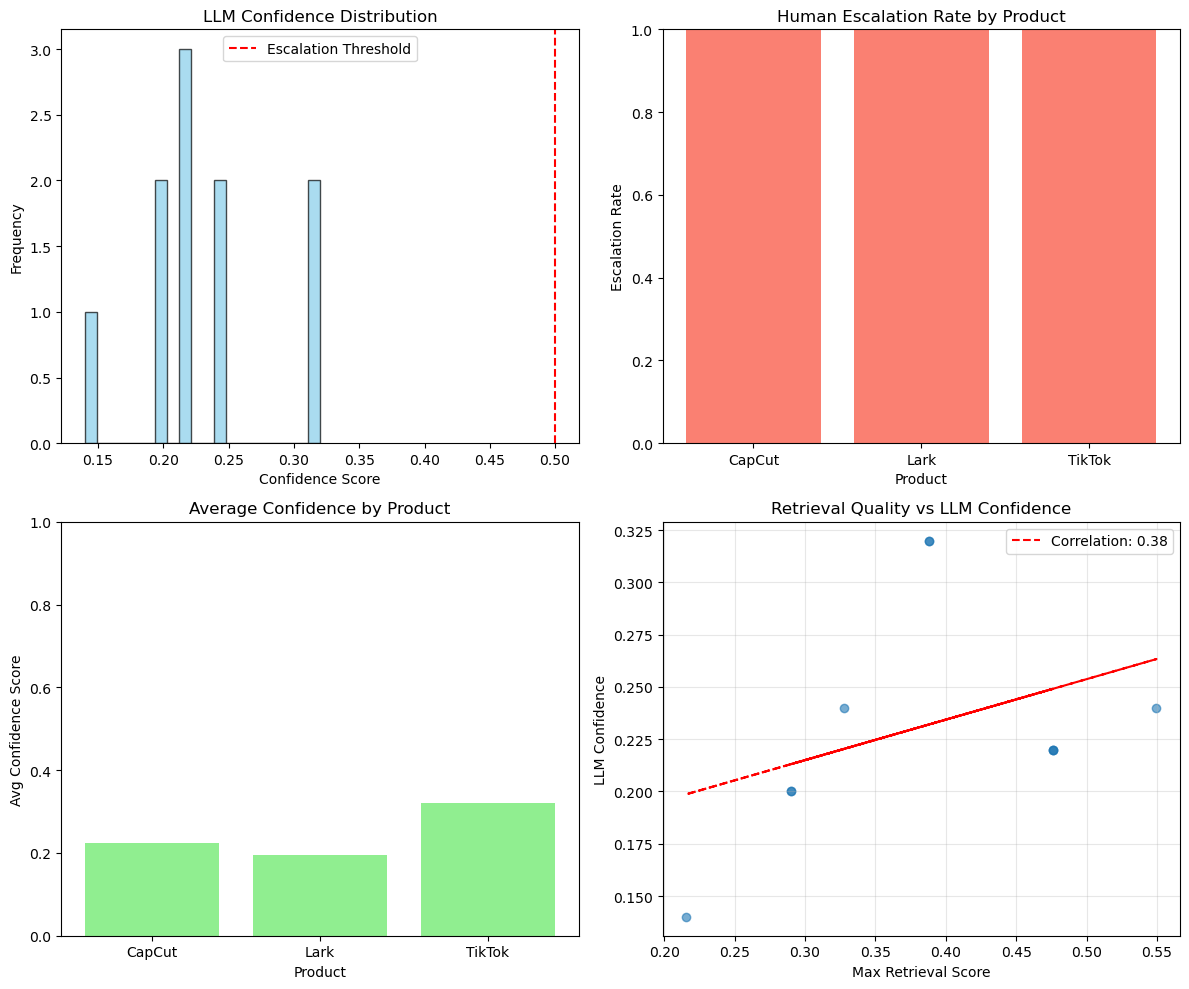

📊 Visualizations saved as 'llm_analysis.png'


In [14]:
# Cell 10: Create visualizations
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Confidence Score Distribution
axes[0,0].hist(results_df['confidence_score'], bins=20, edgecolor='black', alpha=0.7, color='skyblue')
axes[0,0].set_xlabel('Confidence Score')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('LLM Confidence Distribution')
axes[0,0].axvline(x=0.5, color='r', linestyle='--', label='Escalation Threshold')
axes[0,0].legend()

# 2. Confidence by Product
products = results_df.groupby('product')['confidence_score'].mean()
axes[1,0].bar(products.index, products.values, color='lightgreen')
axes[1,0].set_xlabel('Product')
axes[1,0].set_ylabel('Avg Confidence Score')
axes[1,0].set_title('Average Confidence by Product')
axes[1,0].set_ylim([0, 1])

# 3. Escalation by Product
escalation_by_product = results_df.groupby('product')['requires_escalation'].mean()
axes[0,1].bar(escalation_by_product.index, escalation_by_product.values, color='salmon')
axes[0,1].set_xlabel('Product')
axes[0,1].set_ylabel('Escalation Rate')
axes[0,1].set_title('Human Escalation Rate by Product')
axes[0,1].set_ylim([0, 1])

# 4. Retrieval Score vs Confidence Correlation
axes[1,1].scatter(results_df['retrieval_scores'].apply(lambda x: max(x) if x else 0), 
                   results_df['confidence_score'], alpha=0.6)
axes[1,1].set_xlabel('Max Retrieval Score')
axes[1,1].set_ylabel('LLM Confidence')
axes[1,1].set_title('Retrieval Quality vs LLM Confidence')
axes[1,1].grid(True, alpha=0.3)

# Add correlation line
from scipy import stats
if len(results_df) > 1:
    x = results_df['retrieval_scores'].apply(lambda x: max(x) if x else 0)
    y = results_df['confidence_score']
    slope, intercept, r_value, _, _ = stats.linregress(x, y)
    axes[1,1].plot(x, slope*x + intercept, 'r--', label=f'Correlation: {r_value:.2f}')
    axes[1,1].legend()

plt.tight_layout()
plt.savefig('llm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Visualizations saved as 'llm_analysis.png'")

In [16]:
# Cell 11: Interactive demo (test your own queries)
print("="*60)
print("🎮 INTERACTIVE BYTEDANCE SUPPORT DEMO")
print("="*60)
print("Ask questions about TikTok, CapCut, or Lark")
print("Type 'exit' to stop\n")

while True:
    user_query = input("🔍 You: ").strip()
    
    if user_query.lower() in ['exit', 'quit', 'q']:
        print("👋 Thank you for using ByteAssist!")
        break
    
    if not user_query:
        print("   Please enter a question.\n")
        continue
    
    # Retrieve relevant docs
    docs, titles, scores, langs = retrieve(user_query, k=3)
    
    print(f"\n📚 Retrieved from knowledge base:")
    for i, (title, score) in enumerate(zip(titles, scores), 1):
        print(f"   {i}. {title} (relevance: {score:.2%})")
    
    # Generate response
    response = generate_response(user_query, docs, titles, scores, use_mock=not USE_REAL_LLM)
    
    print(f"\n🤖 ByteAssist: {response['answer']}")
    print(f"\n📊 Confidence: {response['confidence_score']:.1%}")
    
    if response['suggested_actions']:
        print(f"\n✅ Suggested actions:")
        for action in response['suggested_actions'][:3]:
            print(f"   • {action}")
    
    if response['requires_human_escalation']:
        print(f"\n⚠️  This issue may require human support escalation")
    
    print("\n" + "-"*40 + "\n")

🎮 INTERACTIVE BYTEDANCE SUPPORT DEMO
Ask questions about TikTok, CapCut, or Lark
Type 'exit' to stop



🔍 You:  How does TikTok’s recommendation algorithm decide what videos to show?



📚 Retrieved from knowledge base:
   1. TikTok Algorithm Guide 2025 (relevance: 75.38%)
   2. Data Privacy at ByteDance (relevance: 41.60%)
   3. Panduan CapCut Bahasa Melayu (relevance: 24.99%)

🤖 ByteAssist: Based on ByteDance documentation: The TikTok algorithm prioritizes watch time (60%), completion rate (25%), and engagement (15%). For best results, post when your audience is active (7... For more help, check our support center.

📊 Confidence: 47.0%

✅ Suggested actions:
   • Check the ByteDance Help Center
   • Try the troubleshooting steps above
   • Contact support if issue persists

⚠️  This issue may require human support escalation

----------------------------------------



🔍 You:  How do I add automatic captions in CapCut?



📚 Retrieved from knowledge base:
   1. Panduan CapCut Bahasa Melayu (relevance: 39.13%)
   2. CapCut Login Troubleshooting (relevance: 31.54%)
   3. TikTok Algorithm Guide 2025 (relevance: 8.10%)

🤖 ByteAssist: Based on ByteDance documentation: Cara atasi masalah eksport CapCut: Pastikan ruang storan mencukupi, tutup aplikasi lain, dan gunakan format eksport H.264 untuk hasil terbaik.... For more help, check our support center.

📊 Confidence: 26.0%

✅ Suggested actions:
   • Check the ByteDance Help Center
   • Try the troubleshooting steps above
   • Contact support if issue persists

⚠️  This issue may require human support escalation

----------------------------------------



🔍 You:  How does Lark compare to Slack for team collaboration?



📚 Retrieved from knowledge base:
   1. Lark Administration Guide (relevance: 30.40%)
   2. TikTok Algorithm Guide 2025 (relevance: 18.14%)
   3. Data Privacy at ByteDance (relevance: 18.03%)

🤖 ByteAssist: Based on ByteDance documentation: Lark supports SSO integration, audit logs, and role-based access control. Admins can configure security policies in Admin Console > Security Settings.... For more help, check our support center.

📊 Confidence: 22.0%

✅ Suggested actions:
   • Check the ByteDance Help Center
   • Try the troubleshooting steps above
   • Contact support if issue persists

⚠️  This issue may require human support escalation

----------------------------------------



🔍 You:  exit


👋 Thank you for using ByteAssist!


In [17]:
# Cell 12: Export to Notebook 4 format
print("="*60)
print("🔗 PREPARING FOR NOTEBOOK 4 (MLFLOW EVALUATION)")
print("="*60)

# Create a combined dataset for MLflow evaluation
mlflow_ready = []

for result in results:
    mlflow_ready.append({
        "query_id": result['ticket_id'],
        "query": result['user_query'],
        "product": result['product'],
        "retrieved_sources": result['sources_used'],
        "max_retrieval_score": max(result['retrieval_scores']) if result['retrieval_scores'] else 0,
        "llm_confidence": result['confidence_score'],
        "requires_escalation": result['requires_escalation'],
        "response_length": len(result['llm_answer'])
    })

mlflow_df = pd.DataFrame(mlflow_ready)
mlflow_df.to_csv('mlflow_evaluation_data.csv', index=False)
print("✅ Saved: mlflow_evaluation_data.csv")

print("\n📊 Preview for Notebook 4:")
print(mlflow_df.head())
print(f"\n📈 Summary statistics for MLflow:")
print(mlflow_df.describe())

🔗 PREPARING FOR NOTEBOOK 4 (MLFLOW EVALUATION)
✅ Saved: mlflow_evaluation_data.csv

📊 Preview for Notebook 4:
          query_id                         query product  \
0  TKT-202605-0001   watermark issue with CapCut  CapCut   
1  TKT-202605-0002   watermark issue with CapCut  CapCut   
2  TKT-202605-0003    follower issue with TikTok  TikTok   
3  TKT-202605-0004  notification issue with Lark    Lark   
4  TKT-202605-0005    follower issue with TikTok  TikTok   

                                   retrieved_sources  max_retrieval_score  \
0  [CapCut Login Troubleshooting, Shadowban Resol...             0.476051   
1  [CapCut Login Troubleshooting, Shadowban Resol...             0.476051   
2  [TikTok Algorithm Guide 2025, Data Privacy at ...             0.387904   
3  [Lark Administration Guide, CapCut Login Troub...             0.290205   
4  [TikTok Algorithm Guide 2025, Data Privacy at ...             0.387904   

   llm_confidence  requires_escalation  response_length  
0       